<a href="https://colab.research.google.com/github/bcramp/ML/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

HW 3

Title: Logistic Regression using SGDClassifier on the Telco Customer Churn Dataset

Name: Brennen Cramp

Date: 9/23/2026

---

# Task 1: Load the dataset into a Pandas DataFrame

In [77]:
# Import Pandas for handling tabular data
# Import NumPy for handling scientific computing and math operations
import pandas as pd
import numpy as np

# Task 1: Since the downloaded CSV was uploaded directly to the Colab session files,
# load the file into a Pandas DataFrame.
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Task 2: Inspect and analyze features **[multiple (6 total) code cells]**

In [78]:
# Task 2: Use structural inspection methods (head(), info(), describe()) to analyze features such as tenure, MonthlyCharges, TotalCharges, Contract, and PaymentMethod.
print("--- Task 2: Inspection ---")
print("\nFirst 5 rows of the dataset:")
df.head()

--- Task 2: Inspection ---

First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [79]:
print("General information about the Telco Customer Churn dataset:\n")
df.info()

print("\nSummary statistics of numerical columns:\n")
df.describe()

General information about the Telco Customer Churn dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-n

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [80]:
# Get summary statistics for specific columns (tenure, MonthlyCharges, TotalCharges, Contract, and PaymentMethod)
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod']].describe()

# IMPORTANT NOTE: TotalCharges, Contract, and PaymentMethod will not appear here since they contain categorical/object data types and are NOT numerical

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [81]:
# Get summary statistics for the TotalCharges column
df['TotalCharges'].describe()

,TotalCharges
count,7043
unique,6531
top,
freq,11


In [82]:
# Get summary statistics for the Contract column
df['Contract'].describe()

,Contract
count,7043
unique,3
top,Month-to-month
freq,3875


In [83]:
# Get summary statistics for the PaymentMethod column
df['PaymentMethod'].describe()

,PaymentMethod
count,7043
unique,4
top,Electronic check
freq,2365


# Task 3: Drop any non-informative identifiers

In [84]:
# Task 3: Drop any non-informative identifiers (such as customerID).
print("--- Task 3: Drop Non-informative Identifiers ---")

# Print the number of unique values in each column
print("\nNumber of unique values in each column:")
print(df.nunique())

# Drop non-informative identifier columns
cols_to_drop = ['customerID']
df.drop(columns=cols_to_drop, axis=1, inplace=True)

# Print which non-informative columns were dropped
print("\nSuccessfully dropped these columns:\n")
print(cols_to_drop)

--- Task 3: Drop Non-informative Identifiers ---

Number of unique values in each column:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

Successfully dropped these columns:

['customerID']


# Task 4: Quantify missing/implicit values and implement a structured imputation strategy **[multiple (2 total) code cells]**

In [85]:
# Task 4.1: Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges).
print("--- Task 4.1: Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges) ---")

# Quantify missing values per column
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

# Check each of the String/Object values for N/A types which can be associated with 'null'
print("\nTotal Charges Value Counts:")
print(df['TotalCharges'].value_counts())

# I see that there are 11 instances of a space (N/A). I will now count how many entries are empty spaces or whitespaces
print(f"\nImplicit missing values (empty spaces/whitespaces) in TotalCharges: {df['TotalCharges'].str.isspace().sum()}")

# Convert whitespaces to NaN and coerce the column to be numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("\nTotalCharges has been converted to a numerical column and whitespaces were converted to NaN!")

# Quantify the missing values per column, again
print("\n--- New Missing Value Counts ---")
print(df.isnull().sum())

print("\nContract Value Counts:")
print(df['Contract'].value_counts())

print("\nPayment Method Value Counts:")
print(df['PaymentMethod'].value_counts())

--- Task 4.1: Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges) ---

--- Missing Value Counts ---
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total Charges Value Counts:
TotalCharges
           11
20.2       11
19.75       9
20.05       8
19.9        8
           ..
130.15      1
3211.9      1
7843.55     1
2196.3      1
197.4       1
Name: count, Length: 6531, dtype: int64

Implicit missing values (empty spaces/whitespaces) in TotalCharges: 11

TotalCharges has been converted to a numerical column and whitespaces were co

In [86]:
# Task 4.2: Implement/define a structured imputation strategy using Scikit-Learn's SimpleImputer.

# Import Scikit-Learn's SimpleImputer to handle missing entries
from sklearn.impute import SimpleImputer

print("--- Task 4.2: Implement/define a structured imputation strategy using Scikit-Learn's SimpleImputer ---")

# --- IMPORTANT NOTE: ---
# I noticed that I used .fit_transform() too early in assignment 2 during this step, on the training data.
# I called it on the entire dataset during this step before splitting it... meaning I calculated the median using
# both training and testing data which would cause data leaks from my testing data into my training phase.
# Now, I will use it (.fit_transform() -> .fit()) within task 7!

# Identify numeric and categorical columns/features in the dataframe
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Next, I want to define the numeric columns using the median (instead of mean due to extreme outliers possibly skewing the mean)
print("Defining the imputer for the numeric columns using the median values per column.")
num_imputer = SimpleImputer(strategy='median')

# Additionally, I want to define the imputer for the categorical columns using the most occurring value
print("Defining the imputer for the categorical columns using the most occurring value per column.")
cat_imputer = SimpleImputer(strategy='most_frequent')

print("Imputation strategies successfully defined!")

--- Task 4.2: Implement/define a structured imputation strategy using Scikit-Learn's SimpleImputer ---
Defining the imputer for the numeric columns using the median values per column.
Defining the imputer for the categorical columns using the most occurring value per column.
Imputation strategies successfully defined!


# Task 5: Isolate numerical/categorical features and apply scaling (numeric) and encoding (categoric) to columns

In [87]:
# Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies
# appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and encoding (OneHotEncoder) to categorical columns.

# Import needed functionalities from Scikit-Learn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("--- Task 5: Isolate features and build preprocessing pipelines ---")

# Create features and target (y - Churn)
features = df.drop(columns=['Churn'])
target = df['Churn']

# Separate numerical/categorical features from the features dataframe
num_features = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = features.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical features that will be scaled:", num_features)
print("Categorical features that will be encoded:", cat_features)

# Create individual pipeline for the numeric features using my median imputer from Task 4.2
num_transformer = Pipeline(steps=[
    ('imputer', num_imputer),
    ('scaler', StandardScaler())
])

# Create individual pipeline for the categorical features using my most fequent imputer from Task 4.2;
# I will also add the drop='first' parameter to avoid multicollinearity for SGDClassifier!
cat_transformer = Pipeline(steps=[
    ('imputer', cat_imputer),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Make the preprocessor by combining the pipelines into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

print("\nSuccessfully built preprocessor pipeline!")

--- Task 5: Isolate features and build preprocessing pipelines ---
Numerical features that will be scaled: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features that will be encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Successfully built preprocessor pipeline!


# Task 6: Append an SGDClassifier configured with loss='log_loss' to pipeline

In [88]:
# Task 6: Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform
# logistic regression and enable probability estimation.

# Import SGDClassifier library from Scikit-Learn
from sklearn.linear_model import SGDClassifier

print("--- Task 6: Append an SGDClassifier to the final pipeline ---")

# Create the SGDClassifier and configure with loss='log_loss' and I will set the random seed to 100
sgd = SGDClassifier(loss='log_loss', random_state=100)

# Chain the preprocessor with the classifier for the final pipeline
complete_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', sgd)
])

print("Successfully appended SGDClassifier to make the complete pipeline!")

--- Task 6: Append an SGDClassifier to the final pipeline ---
Successfully appended SGDClassifier to make the complete pipeline!


# Task 7: Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40), fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC curve. Report on any performance differences detected across the various splitting ratios.

--- Task 7: Evaluating performance across the split ratios (80/20, 70/30, 60/40) ---

-------------------- 80/20 Training-Test Split Evaluation --------------------

Confusion Matrix for 80/20 Training-Test Split:
[[835 200]
 [122 252]]

Classification Report for 80/20 Training-Test Split:
              precision    recall  f1-score   support

          No       0.87      0.81      0.84      1035
         Yes       0.56      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC Score for 80/20 Training-Test Split: 0.8257

-------------------- 70/30 Training-Test Split Evaluation --------------------

Confusion Matrix for 70/30 Training-Test Split:
[[1419  133]
 [ 306  255]]

Classification Report for 70/30 Training-Test Split:
              precision    recall  f1-score   support

          No       0.82      0.91      0.87      1552
         Ye

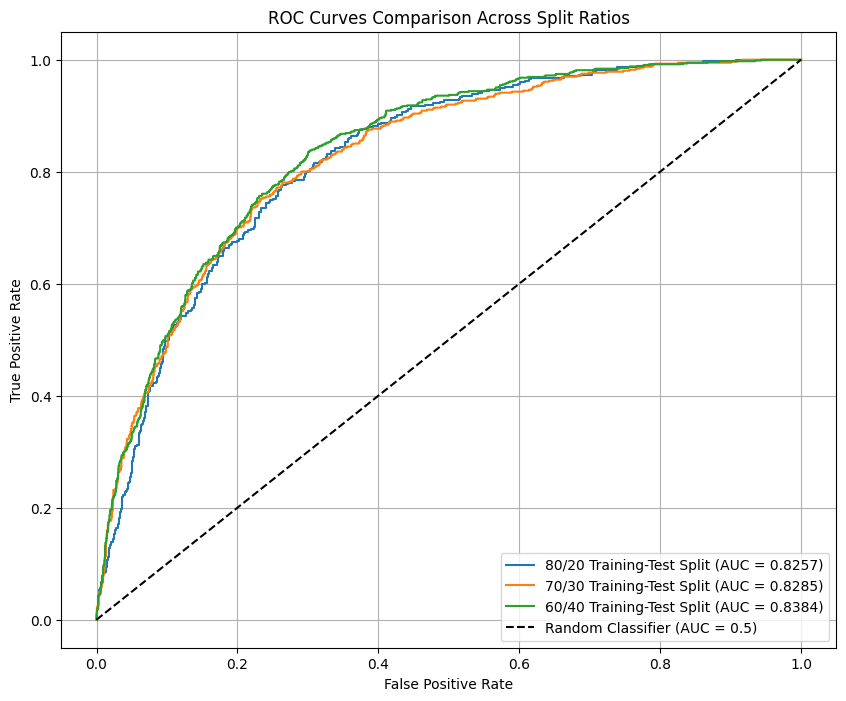

In [91]:
# Task 7: Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40),
# fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC curve.
# Report on any performance differences detected across the various splitting ratios.

# Import needed functionalities from Scikit-Learn and data visualization libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("--- Task 7: Evaluating performance across the split ratios (80/20, 70/30, 60/40) ---")

# Creates the training-test split configs
splits = {
    "80/20 Training-Test Split": 0.20,
    "70/30 Training-Test Split": 0.30,
    "60/40 Training-Test Split": 0.40
}

# Creates one figure for the all the ROC curves
# Set the width of the figure to 10 and height to 8
plt.figure(figsize=(10, 8))

# Iterate through each split
for name, test_ratio in splits.items():
    print(f"\n-------------------- {name} Evaluation --------------------")

    # Splits the data using the features/target vars created during task 5 and I also set the random seed to be 100.
    # I also set the stratify parameter to the target to make sure the balance will be identical.
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=test_ratio, random_state=100, stratify=target
    )

    # IMPORTANT: Fit the pipeline ONLY on the training data to prevent data leakage!!
    # This is where I should use .fit() instead of previously in task 4.2.
    complete_pipe.fit(X_train, y_train)

    # Generate predictions for evals
    # I used [:,1] to get the probability estimates for Churn
    y_pred = complete_pipe.predict(X_test)
    y_prob = complete_pipe.predict_proba(X_test)[:,1]

    # Computes and prints eval metrics (confusion and classification)
    print(f"\nConfusion Matrix for {name}:")
    print(confusion_matrix(y_test, y_pred))

    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))

    # Calcs the ROC_AUC score
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC Score for {name}: {roc_auc:.4f}")

    # Calcs and plots the ROC curve data
    # I do not care about the 3rd returned value so it will be 'ignored'
    # pos_label is also set to 'Yes' since Churn has 'Yes'/'No' values, not a numerical value
    false_pos_rate, true_pos_rate, ignored = roc_curve(y_test, y_prob, pos_label='Yes')
    plt.plot(false_pos_rate, true_pos_rate, label=f'{name} (AUC = {roc_auc:.4f})')


# Styling for the combined ROC plot
# Colab auto-included 'k--' and the lael which I think looks good, so I kept it in!
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison Across Split Ratios')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Task 8: Generate a 2D decision boundary visualization or inspect model feature coefficients

--- Task 8: Extracting and interpreting model feature coefficients ---


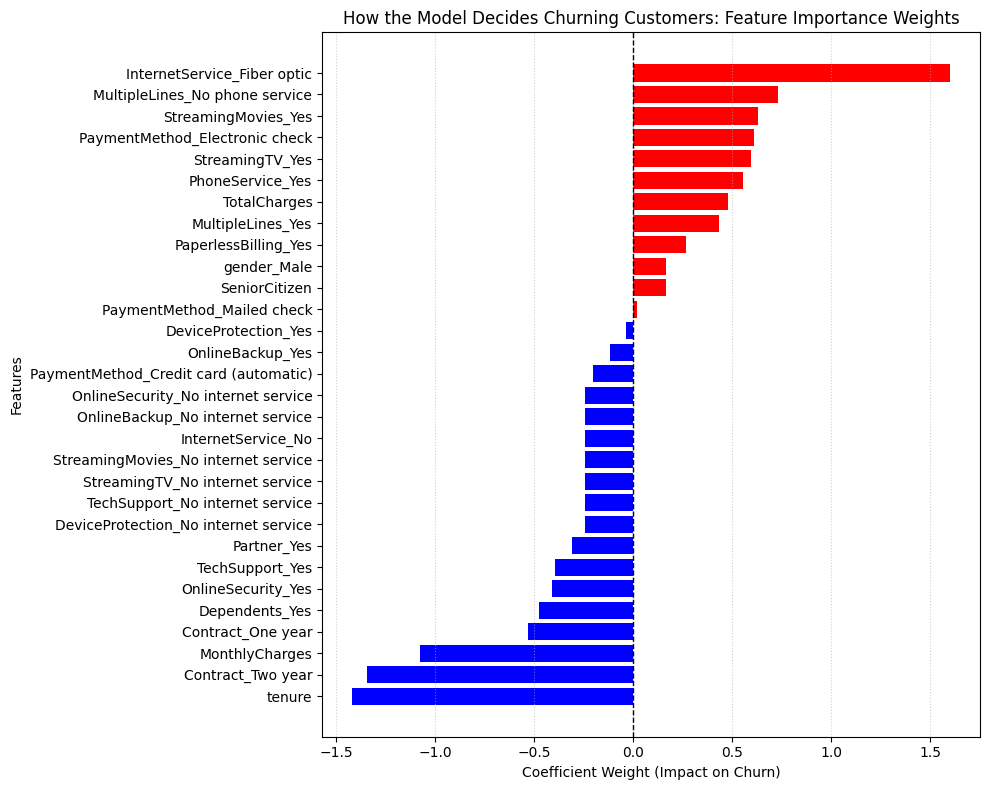


Top 5 features driving customers to leave (positive coefficients):
                           Feature  Coefficient
10     InternetService_Fiber optic     1.601344
8   MultipleLines_No phone service     0.730856
23             StreamingMovies_Yes     0.629096
28  PaymentMethod_Electronic check     0.608227
21                 StreamingTV_Yes     0.596998

Top 5 features preventing customers from leaving (negative coefficients):
              Feature  Coefficient
1              tenure    -1.421658
25  Contract_Two year    -1.346579
2      MonthlyCharges    -1.079748
24  Contract_One year    -0.533206
6      Dependents_Yes    -0.474314


In [92]:
# Task 8: Generate a 2D decision boundary visualization or inspect model feature coefficients to interpret how the model separates churning customers from retained customers.
print("--- Task 8: Extracting and interpreting model feature coefficients ---")

# Extracts the fitted preprocessor and classifier from the completed pipeline
fitted_preprocessor = complete_pipe.named_steps['preprocessor']
fitted_classifier = complete_pipe.named_steps['classifier']

# Pulls the categorical feature names and finds the encoder
cat_encoder = fitted_preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_names = cat_encoder.get_feature_names_out(cat_features).tolist()

# Combines all features names back together
all_features = num_features + cat_names

# Retrieves the model weights by extracting the flat array of weights
weights = fitted_classifier.coef_[0]

# Builds a new frame to view/sort weights
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': weights
})

# Sorts the weights/coefficients by the magnitude of impact
coef_df['Absolute_Magnitude'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Coefficient', ascending=True)

# Iterate through each coefficient to create colors list
colors = []
for coeff in coef_df['Coefficient']:
    if coeff > 0:
        colors.append('red')
    else:
        colors.append('blue')

# Creates figure for the coefficients
# Set the width of the figure to 10 and height to 8
plt.figure(figsize=(10, 8))

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Coefficient Weight (Impact on Churn)')
plt.ylabel('Features')
plt.title('How the Model Decides Churning Customers: Feature Importance Weights')
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nTop 5 features driving customers to leave (positive coefficients):")
print(coef_df[coef_df['Coefficient'] > 0].tail(5)[::-1][['Feature', 'Coefficient']])

print("\nTop 5 features preventing customers from leaving (negative coefficients):")
print(coef_df[coef_df['Coefficient'] < 0].head(5)[['Feature', 'Coefficient']])